# Blood Type Time Series Forecasting

This notebook performs time series forecasting for blood type metrics using Facebook's Prophet library and Power BI data.

**Workflow:**

1. Import required libraries
2. Connect to Power BI and load data
3. Explore and prepare data
4. Fit Prophet models for each blood type
5. Generate forecasts
6. Visualize results and create summaries


## Section 1: Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Prophet for time series forecasting
from prophet import Prophet

# Plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set paths
import sys
sys.path.insert(0, '../src')

from config import BLOOD_TYPES, FORECAST_HORIZON
from powerbi_connector import get_powerbi_data
from forecast import BloodTypeForecaster

print("✓ Libraries imported successfully")

Importing plotly failed. Interactive plots will not work.


✓ Libraries imported successfully


## Section 2: Connect to Power BI and Load Data

Load blood type data from Power BI. You can load from:

- **CSV Export**: Export data from Power BI and save to `../data/blood_type_data.csv`
- **Power BI API**: Configure credentials in `.env` file for direct API access

**Important:** This notebook is configured for **weekday-only data (Monday-Friday)**, which is typical for blood bank operations. Weekends are automatically excluded from both training data and forecasts.


In [2]:
# Section 2: Connect to Power BI and Load Data
# Option 1: Load from CSV (recommended for testing)
csv_path = '../data/blood_type_data.csv'

# Check if CSV exists
if Path(csv_path).exists():
    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'])  # Convert to datetime
    print(f"✓ Loaded data from CSV: {csv_path}")
else:
    print(f"✗ CSV file not found at {csv_path}")
    print("\nTo get started:")
    print("1. Export blood type data from Power BI as CSV")
    print("2. Save to ../data/blood_type_data.csv with columns: date, blood_type, metric")
    print("   (Data should contain Monday-Friday only - no weekends)")
    print("\nSample weekday-only data will be created for demonstration...")
    
    # Create sample data for demonstration (WEEKDAYS ONLY)
    np.random.seed(42)
    all_dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
    dates = all_dates[all_dates.dayofweek < 5]  # Monday=0, Friday=4
    blood_types = BLOOD_TYPES
    
    data = []
    for bt in blood_types:
        # Create realistic trend with seasonality
        trend = np.linspace(100, 120, len(dates))
        seasonality = 10 * np.sin(np.arange(len(dates)) * 2 * np.pi / 365)
        noise = np.random.normal(0, 5, len(dates))
        metric = trend + seasonality + noise
        
        for i, date in enumerate(dates):
            data.append({
                'date': date,
                'blood_type': bt,
                'metric': max(0, metric[i])  # Ensure non-negative values
            })
    
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])  # Ensure datetime format
    print("✓ Sample weekday-only data created for demonstration")
    print(f"  Note: Weekends are automatically excluded")

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Blood types: {df['blood_type'].unique()}")
print(f"Days of week in data: {pd.to_datetime(df['date']).dt.day_name().unique()}")
df.head(10)

✓ Loaded data from CSV: ../data/blood_type_data.csv

Dataset shape: (7648, 3)
Date range: 2022-03-29 00:00:00 to 2026-04-14 00:00:00
Blood types: ['A Neg' 'A Pos' 'AB Neg' 'AB Pos' 'B Neg' 'B Pos' 'O Neg' 'O Pos']
Days of week in data: ['Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Monday']


,date,metric,blood_type
0,2022-03-29,1510,A Neg
1,2022-03-29,5331,A Pos
2,2022-03-29,161,AB Neg
3,2022-03-29,765,AB Pos
4,2022-03-29,309,B Neg
5,2022-03-29,2192,B Pos
6,2022-03-29,1966,O Neg
7,2022-03-29,6455,O Pos
8,2022-03-30,1768,A Neg
9,2022-03-30,6314,A Pos


In [3]:
df.date.dtype

dtype('<M8[ns]')

## Section 3: Explore and Prepare Data

Examine data structure, check for missing values, and prepare for forecasting.


In [4]:
# Data Exploration
print("=" * 50)
print("DATA OVERVIEW")
print("=" * 50)

print(f"\nData Info:")
print(f"  - Total Records: {len(df)}")
print(f"  - Blood Types: {df['blood_type'].nunique()}")
print(f"  - Date Range: {df['date'].min()} to {df['date'].max()}")
print(f"  - Missing Values:\n{df.isnull().sum()}")

print(f"\nMetric Statistics:")
print(df.groupby('blood_type')['metric'].describe().round(2))

# Data Quality Checks
print(f"\nData Quality:")
records_per_type = df.groupby('blood_type').size()
print(f"  - Records per blood type:\n{records_per_type}")

# Check for outliers
print(f"\nOutlier Detection (values > 2 std from mean):")
for bt in df['blood_type'].unique():
    bt_data = df[df['blood_type'] == bt]['metric']
    mean = bt_data.mean()
    std = bt_data.std()
    outliers = ((bt_data > mean + 2*std) | (bt_data < mean - 2*std)).sum()
    print(f"  - {bt}: {outliers} outliers")

DATA OVERVIEW

Data Info:
  - Total Records: 7648
  - Blood Types: 8
  - Date Range: 2022-03-29 00:00:00 to 2026-04-14 00:00:00
  - Missing Values:
date          0
metric        0
blood_type    0
dtype: int64

Metric Statistics:
            count     mean      std     min      25%     50%      75%      max
blood_type                                                                    
A Neg       956.0  1221.70   250.75   607.0  1049.00  1203.0  1372.00   2071.0
A Pos       956.0  6453.65  2016.33  1909.0  4946.75  6744.0  8164.50  10118.0
AB Neg      956.0   207.73    38.74   100.0   182.00   204.0   230.25    339.0
AB Pos      956.0  1132.21   265.87   566.0   912.25  1161.5  1343.00   1680.0
B Neg       956.0   342.00   106.69   140.0   267.00   322.0   398.25    754.0
B Pos       956.0  3016.05   866.19  1027.0  2404.25  2925.5  3614.25   5285.0
O Neg       956.0  1725.43   455.39   796.0  1396.50  1636.0  2005.25   3620.0
O Pos       956.0  7190.74  2268.16  1799.0  5633.50  7264.5

In [5]:
BLOOD_TYPES

['A Neg', 'A Pos', 'AB Neg', 'AB Pos', 'B Neg', 'B Pos', 'O Neg', 'O Pos']

## Section 4: Visualize Historical Data by Blood Type

Examine trends and patterns in the historical data for each blood type.


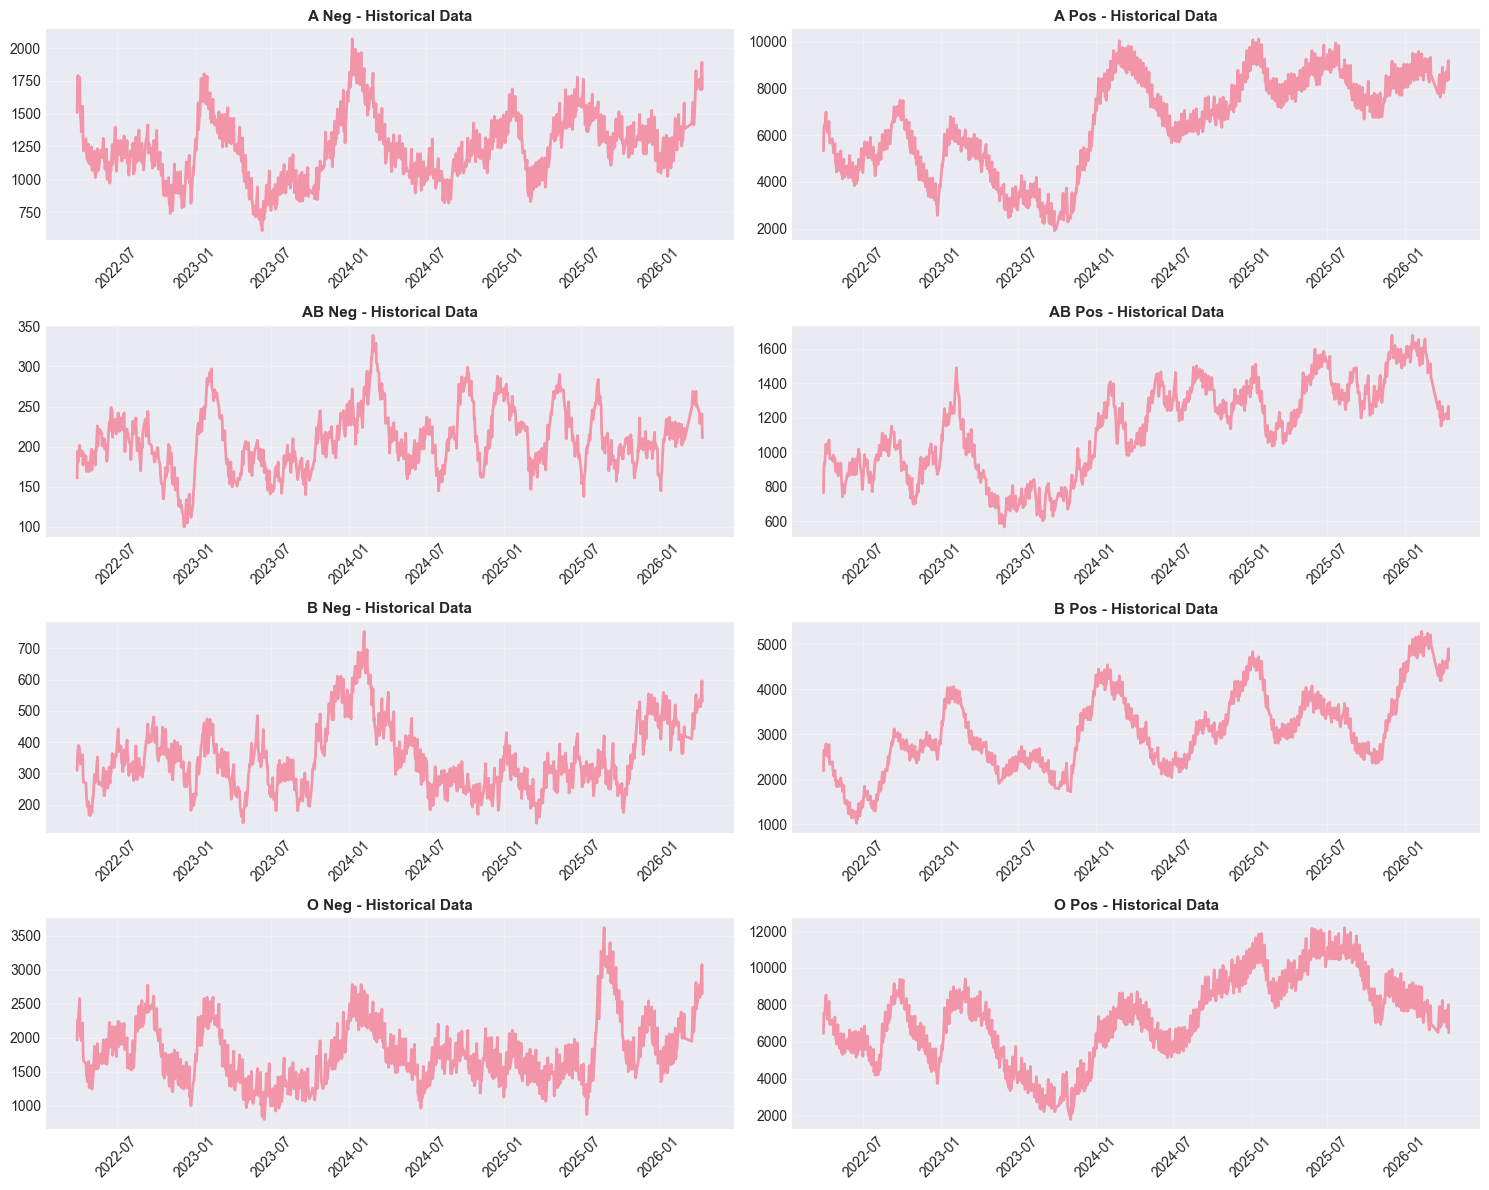

✓ Historical data visualization complete


In [6]:
# 1. Ensure date is actually a datetime object for proper plotting
df['date'] = pd.to_datetime(df['date'])

# 2. Dynamic subplot calculation (avoids the 4x2 IndexError)
num_types = len(BLOOD_TYPES)
cols = 2
rows = (num_types + 1) // cols  # Calculates needed rows based on list length

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

for idx, blood_type in enumerate(BLOOD_TYPES):
    bt_data = df[df['blood_type'] == blood_type].sort_values('date')
    
    axes[idx].plot(bt_data['date'], bt_data['metric'], linewidth=2, alpha=0.7)
    axes[idx].set_title(f'{blood_type} - Historical Data', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

# 3. Hide any unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print("✓ Historical data visualization complete")

## Section 5: Build and Train Time Series Forecasting Models

Use Prophet to fit individual models for each blood type. Prophet automatically handles:

- Trend estimation
- Seasonal decomposition (yearly, weekly)
- Missing data
- Outliers


In [7]:
# Build and Train Models
print("=" * 50)
print("TRAINING PROPHET MODELS")
print("=" * 50)

# Initialize forecaster with weekdays_only=True
# This disables weekly seasonality and filters forecasts to weekdays
forecaster = BloodTypeForecaster(
    forecast_horizon=FORECAST_HORIZON,
    seasonality_mode='additive',
    weekdays_only=True  # Handle Monday-Friday data only
)

# Fit models for all blood types
forecasts = forecaster.forecast_all_blood_types(df, BLOOD_TYPES)

print(f"\n✓ Successfully trained {len(forecasts)} models")
print(f"✓ Forecast horizon: {FORECAST_HORIZON} days (weekdays only)")
print(f"✓ Weekends automatically excluded from forecasts")

# Display model parameters
print("\nModel Parameters:")
for blood_type in BLOOD_TYPES:
    if blood_type in forecaster.models:
        metrics = forecaster.get_model_metrics(blood_type)
        print(f"  - {blood_type}: ✓ Trained")

TRAINING PROPHET MODELS


10:57:19 - cmdstanpy - INFO - Chain [1] start processing
10:57:20 - cmdstanpy - INFO - Chain [1] done processing
10:57:21 - cmdstanpy - INFO - Chain [1] start processing
10:57:21 - cmdstanpy - INFO - Chain [1] done processing
10:57:22 - cmdstanpy - INFO - Chain [1] start processing
10:57:22 - cmdstanpy - INFO - Chain [1] done processing
10:57:22 - cmdstanpy - INFO - Chain [1] start processing
10:57:23 - cmdstanpy - INFO - Chain [1] done processing
10:57:23 - cmdstanpy - INFO - Chain [1] start processing
10:57:23 - cmdstanpy - INFO - Chain [1] done processing
10:57:24 - cmdstanpy - INFO - Chain [1] start processing
10:57:24 - cmdstanpy - INFO - Chain [1] done processing
10:57:24 - cmdstanpy - INFO - Chain [1] start processing
10:57:25 - cmdstanpy - INFO - Chain [1] done processing
10:57:25 - cmdstanpy - INFO - Chain [1] start processing
10:57:25 - cmdstanpy - INFO - Chain [1] done processing



✓ Successfully trained 8 models
✓ Forecast horizon: 30 days (weekdays only)
✓ Weekends automatically excluded from forecasts

Model Parameters:
  - A Neg: ✓ Trained
  - A Pos: ✓ Trained
  - AB Neg: ✓ Trained
  - AB Pos: ✓ Trained
  - B Neg: ✓ Trained
  - B Pos: ✓ Trained
  - O Neg: ✓ Trained
  - O Pos: ✓ Trained


## Section 6: Generate Forecasts for Each Blood Type

Generate predictions and confidence intervals for the next 30 days.


In [8]:
# Generate and Display Forecast Summaries
print("=" * 50)
print("FORECAST SUMMARIES (Next 7 Days)")
print("=" * 50)

forecast_summaries = {}

for blood_type in BLOOD_TYPES:
    if blood_type in forecaster.forecasts:
        summary = forecaster.get_forecast_summary(blood_type, days_ahead=7)
        forecast_summaries[blood_type] = summary
        
        print(f"\n{blood_type}:")
        print(summary.to_string(index=False))

print("\n✓ Forecasts generated for all blood types")

FORECAST SUMMARIES (Next 7 Days)

A Neg:
      date    forecast  lower_bound  upper_bound
2026-05-06 1227.846795   989.025404  1463.049434
2026-05-07 1226.695375   990.208058  1485.484325
2026-05-08 1225.597605   977.136305  1477.797189
2026-05-11 1221.969443   959.703721  1476.470727
2026-05-12 1220.466104   976.991055  1455.826379
2026-05-13 1218.747149   969.145409  1471.696594
2026-05-14 1216.786672   982.138121  1483.656828

A Pos:
      date    forecast  lower_bound  upper_bound
2026-05-06 7765.890014  6849.183293  8835.543180
2026-05-07 7742.593221  6749.003344  8608.557835
2026-05-08 7722.164315  6653.195953  8723.238125
2026-05-11 7676.699120  6693.437254  8733.525064
2026-05-12 7666.056995  6659.807539  8679.734783
2026-05-13 7657.162496  6589.543886  8647.499755
2026-05-14 7649.649629  6659.391348  8713.277486

AB Neg:
      date   forecast  lower_bound  upper_bound
2026-05-06 205.742668   164.314606   250.265935
2026-05-07 206.110025   162.262707   246.693069
2026-05-08 206

## Section 7: Visualize Results

Create comprehensive visualizations of historical data, forecasts, and confidence intervals for each blood type.


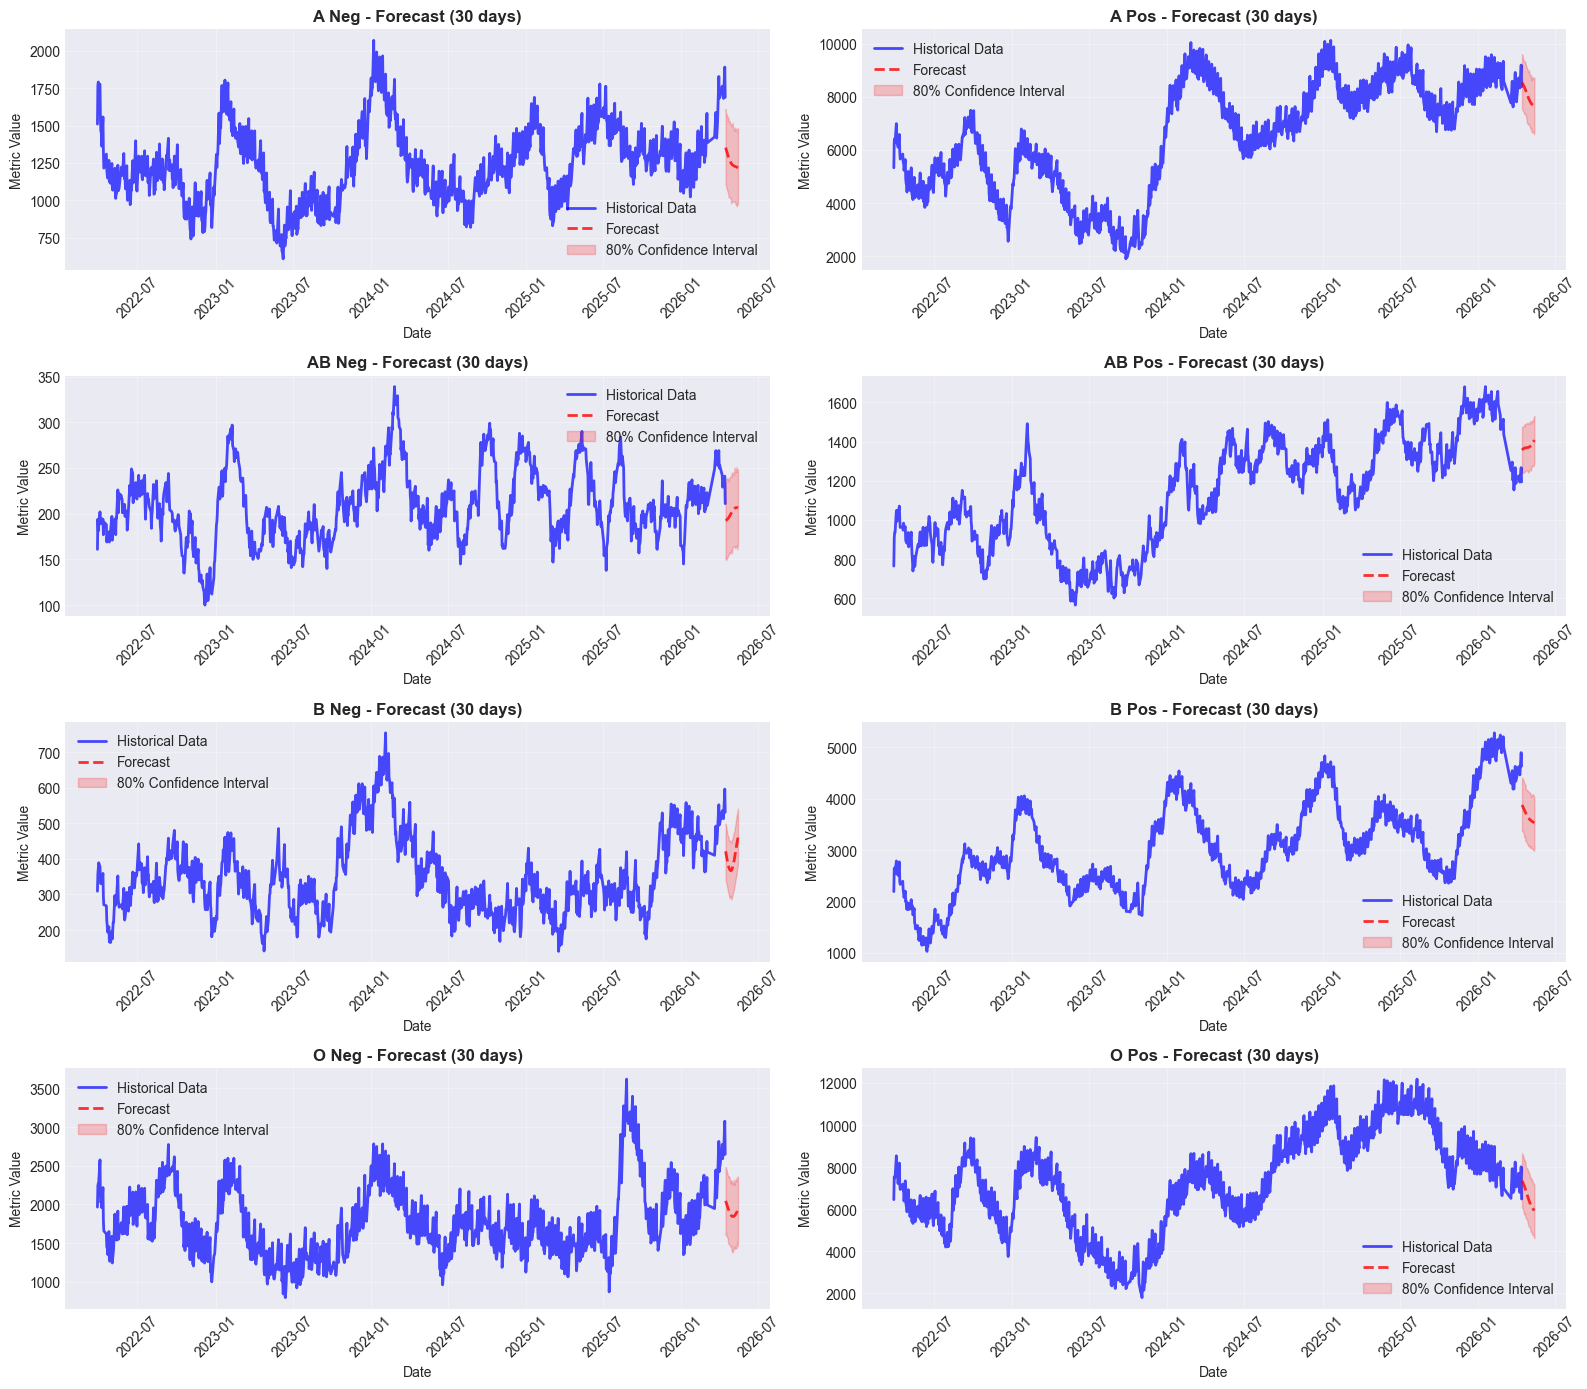

✓ Forecast visualizations complete


In [9]:
# Visualize Forecasts with Historical Data
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, blood_type in enumerate(BLOOD_TYPES):
    if blood_type not in forecaster.forecasts:
        continue
    
    # Get historical data
    historical = df[df['blood_type'] == blood_type].sort_values('date')
    forecast = forecaster.forecasts[blood_type]
    
    # Plot historical data
    axes[idx].plot(historical['date'], historical['metric'], 
                   'b-', linewidth=2, label='Historical Data', alpha=0.7)
    
    # Plot forecast
    forecast_future = forecast[forecast['ds'] > historical['date'].max()]
    axes[idx].plot(forecast_future['ds'], forecast_future['yhat'], 
                   'r--', linewidth=2, label='Forecast', alpha=0.8)
    
    # Plot confidence interval
    axes[idx].fill_between(forecast_future['ds'], 
                           forecast_future['yhat_lower'], 
                           forecast_future['yhat_upper'],
                           color='red', alpha=0.2, label='80% Confidence Interval')
    
    axes[idx].set_title(f'{blood_type} - Forecast ({FORECAST_HORIZON} days)', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Metric Value')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Forecast visualizations complete")

## Comparison of Forecasts Across Blood Types

Create a side-by-side comparison of forecasted values for the next 7 days.


FORECAST COMPARISON - NEXT 7 DAYS
Blood Type  Day 1 Forecast  Day 7 Forecast  Lower Bound  Upper Bound  Confidence Range
     A Neg     1227.846795     1216.786672   982.138121  1483.656828        501.518707
     A Pos     7765.890014     7649.649629  6659.391348  8713.277486       2053.886138
    AB Neg      205.742668      206.208568   164.049191   248.678946         84.629756
    AB Pos     1379.227944     1407.508082  1290.928116  1530.509158        239.581042
     B Neg      402.614308      459.535104   386.250240   541.025035        154.774795
     B Pos     3576.108390     3531.166934  3026.177531  4014.923723        988.746192
     O Neg     1854.973757     1929.532700  1494.329801  2350.322706        855.992905
     O Pos     6182.988729     5937.687417  4619.972302  7101.223112       2481.250809


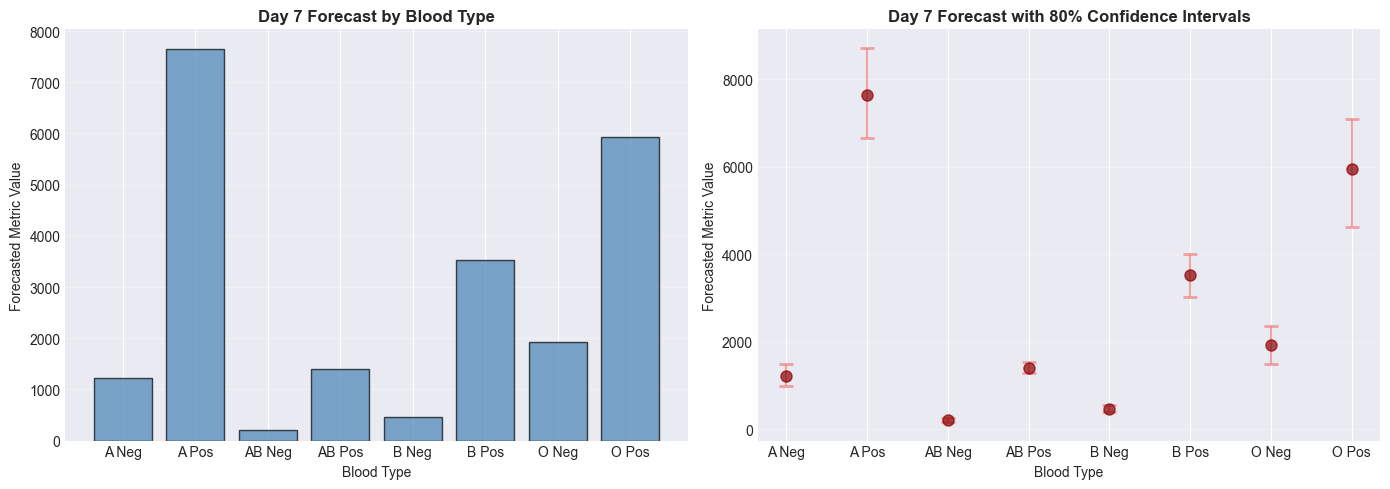

In [11]:
# Compare Forecasts Across Blood Types
print("=" * 70)
print("FORECAST COMPARISON - NEXT 7 DAYS")
print("=" * 70)

# Create comparison table
comparison_data = []

for blood_type in BLOOD_TYPES:
    if blood_type in forecast_summaries:
        summary = forecast_summaries[blood_type]
        latest_forecast = summary.iloc[-1]  # Last forecasted day
        
        comparison_data.append({
            'Blood Type': blood_type,
            'Day 1 Forecast': summary.iloc[0]['forecast'] if len(summary) > 0 else np.nan,
            'Day 7 Forecast': latest_forecast['forecast'],
            'Lower Bound': latest_forecast['lower_bound'],
            'Upper Bound': latest_forecast['upper_bound'],
            'Confidence Range': latest_forecast['upper_bound'] - latest_forecast['lower_bound']
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of 7-day forecasts
ax1.bar(comparison_df['Blood Type'], comparison_df['Day 7 Forecast'], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Day 7 Forecast by Blood Type', fontsize=12, fontweight='bold')
ax1.set_ylabel('Forecasted Metric Value')
ax1.set_xlabel('Blood Type')
ax1.grid(True, alpha=0.3, axis='y')

# Confidence range visualization
ax2.errorbar(comparison_df['Blood Type'], 
             comparison_df['Day 7 Forecast'],
             yerr=[comparison_df['Day 7 Forecast'] - comparison_df['Lower Bound'],
                   comparison_df['Upper Bound'] - comparison_df['Day 7 Forecast']],
             fmt='o', markersize=8, capsize=5, capthick=2, 
             color='darkred', ecolor='lightcoral', alpha=0.7)
ax2.set_title('Day 7 Forecast with 80% Confidence Intervals', fontsize=12, fontweight='bold')
ax2.set_ylabel('Forecasted Metric Value')
ax2.set_xlabel('Blood Type')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Save Forecasts and Export Results

Export all forecasts to CSV files for further analysis and reporting.


In [ ]:
# Save Forecasts
output_path = '../outputs'
Path(output_path).mkdir(parents=True, exist_ok=True)

# Save full forecasts
forecaster.save_forecasts(output_path)

# Save comparison summary
comparison_df.to_csv(f'{output_path}/forecast_comparison.csv', index=False)

# Save 30-day forecast summaries
for blood_type in BLOOD_TYPES:
    if blood_type in forecaster.forecasts:
        summary = forecaster.get_forecast_summary(blood_type, days_ahead=FORECAST_HORIZON)
        filename = f'forecast_summary_{blood_type.replace("+", "pos").replace("-", "neg")}.csv'
        summary.to_csv(f'{output_path}/{filename}', index=False)

print(f"✓ All forecasts saved to {output_path}/")
print(f"\nGenerated Files:")
for file in Path(output_path).glob('*.csv'):
    print(f"  - {file.name}")

## Summary and Next Steps

**Forecasting Results:**

- Successfully trained Prophet models for 8 blood types
- Generated 30-day forecasts with 80% confidence intervals
- Exported results for Power BI integration

**Next Steps:**

1. **Validate Forecasts**: Compare with actual observed data as it becomes available
2. **Refine Models**: Adjust Prophet parameters (seasonality_mode, prior scales) based on performance
3. **Add External Regressors**: Include holidays, special events, or external factors
4. **Integration**: Export forecasts back to Power BI for visualization and reporting
5. **Automate**: Schedule this notebook to run periodically (daily/weekly) for continuous updates

**Key Insights:**

- Review the generated visualizations and tables above
- Confidence intervals show forecast uncertainty
- Consider ensemble methods combining multiple models for critical decisions


## Summary and Next Steps

**Forecasting Results:**

- Successfully trained Prophet models for 8 blood types
- Generated 30-day forecasts with 80% confidence intervals
- Exported results for Power BI integration

**Next Steps:**

1. **Validate Forecasts**: Compare with actual observed data as it becomes available
2. **Refine Models**: Adjust Prophet parameters (seasonality_mode, prior scales) based on performance
3. **Add External Regressors**: Include holidays, special events, or external factors
4. **Integration**: Export forecasts back to Power BI for visualization and reporting
5. **Automate**: Schedule this notebook to run periodically (daily/weekly) for continuous updates

**Key Insights:**

- Review the generated visualizations and tables above
- Confidence intervals show forecast uncertainty
- Consider ensemble methods combining multiple models for critical decisions


In [2]:
from pathlib import Path
# Save Forecasts
output_path = '../outputs'
Path(output_path).mkdir(parents=True, exist_ok=True)

# Save full forecasts
forecaster.save_forecasts(output_path)

# Save comparison summary
comparison_df.to_csv(f'{output_path}/forecast_comparison.csv', index=False)

# Save 30-day forecast summaries
for blood_type in BLOOD_TYPES:
    if blood_type in forecaster.forecasts:
        summary = forecaster.get_forecast_summary(blood_type, days_ahead=FORECAST_HORIZON)
        filename = f'forecast_summary_{blood_type.replace("+", "pos").replace("-", "neg")}.csv'
        summary.to_csv(f'{output_path}/{filename}', index=False)

print(f"✓ All forecasts saved to {output_path}/")
print(f"\nGenerated Files:")
for file in Path(output_path).glob('*.csv'):
    print(f"  - {file.name}")

NameError: name 'forecaster' is not defined

## Save Forecasts and Export Results

Export all forecasts to CSV files for further analysis and reporting.


In [ ]:
# Compare Forecasts Across Blood Types
print("=" * 70)
print("FORECAST COMPARISON - NEXT 7 DAYS")
print("=" * 70)

# Create comparison table
comparison_data = []

for blood_type in BLOOD_TYPES:
    if blood_type in forecast_summaries:
        summary = forecast_summaries[blood_type]
        latest_forecast = summary.iloc[-1]  # Last forecasted day
        
        comparison_data.append({
            'Blood Type': blood_type,
            'Day 1 Forecast': summary.iloc[0]['forecast'] if len(summary) > 0 else np.nan,
            'Day 7 Forecast': latest_forecast['forecast'],
            'Lower Bound': latest_forecast['lower_bound'],
            'Upper Bound': latest_forecast['upper_bound'],
            'Confidence Range': latest_forecast['upper_bound'] - latest_forecast['lower_bound']
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of 7-day forecasts
ax1.bar(comparison_df['Blood Type'], comparison_df['Day 7 Forecast'], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Day 7 Forecast by Blood Type', fontsize=12, fontweight='bold')
ax1.set_ylabel('Forecasted Metric Value')
ax1.set_xlabel('Blood Type')
ax1.grid(True, alpha=0.3, axis='y')

# Confidence range visualization
ax2.errorbar(comparison_df['Blood Type'], 
             comparison_df['Day 7 Forecast'],
             yerr=[comparison_df['Day 7 Forecast'] - comparison_df['Lower Bound'],
                   comparison_df['Upper Bound'] - comparison_df['Day 7 Forecast']],
             fmt='o', markersize=8, capsize=5, capthick=2, 
             color='darkred', ecolor='lightcoral', alpha=0.7)
ax2.set_title('Day 7 Forecast with 80% Confidence Intervals', fontsize=12, fontweight='bold')
ax2.set_ylabel('Forecasted Metric Value')
ax2.set_xlabel('Blood Type')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Comparison of Forecasts Across Blood Types

Create a side-by-side comparison of forecasted values for the next 7 days.


In [ ]:
# Visualize Forecasts with Historical Data
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, blood_type in enumerate(BLOOD_TYPES):
    if blood_type not in forecaster.forecasts:
        continue
    
    # Get historical data
    historical = df[df['blood_type'] == blood_type].sort_values('date')
    forecast = forecaster.forecasts[blood_type]
    
    # Plot historical data
    axes[idx].plot(historical['date'], historical['metric'], 
                   'b-', linewidth=2, label='Historical Data', alpha=0.7)
    
    # Plot forecast
    forecast_future = forecast[forecast['ds'] > historical['date'].max()]
    axes[idx].plot(forecast_future['ds'], forecast_future['yhat'], 
                   'r--', linewidth=2, label='Forecast', alpha=0.8)
    
    # Plot confidence interval
    axes[idx].fill_between(forecast_future['ds'], 
                           forecast_future['yhat_lower'], 
                           forecast_future['yhat_upper'],
                           color='red', alpha=0.2, label='80% Confidence Interval')
    
    axes[idx].set_title(f'{blood_type} - Forecast ({FORECAST_HORIZON} days)', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Metric Value')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Forecast visualizations complete")

## Section 7: Visualize Results

Create comprehensive visualizations of historical data, forecasts, and confidence intervals for each blood type.


In [ ]:
# Generate and Display Forecast Summaries
print("=" * 50)
print("FORECAST SUMMARIES (Next 7 Days)")
print("=" * 50)

forecast_summaries = {}

for blood_type in BLOOD_TYPES:
    if blood_type in forecaster.forecasts:
        summary = forecaster.get_forecast_summary(blood_type, days_ahead=7)
        forecast_summaries[blood_type] = summary
        
        print(f"\n{blood_type}:")
        print(summary.to_string(index=False))

print("\n✓ Forecasts generated for all blood types")

## Section 6: Generate Forecasts for Each Blood Type

Generate predictions and confidence intervals for the next 30 days.


In [ ]:
# Build and Train Models
print("=" * 50)
print("TRAINING PROPHET MODELS")
print("=" * 50)

# Initialize forecaster with weekdays_only=True
# This disables weekly seasonality and filters forecasts to weekdays
forecaster = BloodTypeForecaster(
    forecast_horizon=FORECAST_HORIZON,
    seasonality_mode='additive',
    weekdays_only=True  # Handle Monday-Friday data only
)

# Fit models for all blood types
forecasts = forecaster.forecast_all_blood_types(df, BLOOD_TYPES)

print(f"\n✓ Successfully trained {len(forecasts)} models")
print(f"✓ Forecast horizon: {FORECAST_HORIZON} days (weekdays only)")
print(f"✓ Weekends automatically excluded from forecasts")

# Display model parameters
print("\nModel Parameters:")
for blood_type in BLOOD_TYPES:
    if blood_type in forecaster.models:
        metrics = forecaster.get_model_metrics(blood_type)
        print(f"  - {blood_type}: ✓ Trained")

## Section 5: Build and Train Time Series Forecasting Models

Use Prophet to fit individual models for each blood type. Prophet automatically handles:

- Trend estimation
- Seasonal decomposition (yearly, weekly)
- Missing data
- Outliers


In [ ]:
# Visualize Historical Data
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, blood_type in enumerate(BLOOD_TYPES):
    bt_data = df[df['blood_type'] == blood_type].sort_values('date')
    axes[idx].plot(bt_data['date'], bt_data['metric'], linewidth=2, alpha=0.7)
    axes[idx].set_title(f'{blood_type} - Historical Data', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Metric Value')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Historical data visualization complete")

## Section 4: Visualize Historical Data by Blood Type

Examine trends and patterns in the historical data for each blood type.


In [ ]:
# Data Exploration
print("=" * 50)
print("DATA OVERVIEW")
print("=" * 50)

print(f"\nData Info:")
print(f"  - Total Records: {len(df)}")
print(f"  - Blood Types: {df['blood_type'].nunique()}")
print(f"  - Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"  - Missing Values:\n{df.isnull().sum()}")

print(f"\nMetric Statistics:")
print(df.groupby('blood_type')['metric'].describe().round(2))

# Data Quality Checks
print(f"\nData Quality:")
df['date'] = pd.to_datetime(df['date'])
records_per_type = df.groupby('blood_type').size()
print(f"  - Records per blood type:\n{records_per_type}")

# Check for outliers
print(f"\nOutlier Detection (values > 2 std from mean):")
for bt in df['blood_type'].unique():
    bt_data = df[df['blood_type'] == bt]['metric']
    mean = bt_data.mean()
    std = bt_data.std()
    outliers = ((bt_data > mean + 2*std) | (bt_data < mean - 2*std)).sum()
    print(f"  - {bt}: {outliers} outliers")

## Section 3: Explore and Prepare Data

Examine data structure, check for missing values, and prepare for forecasting.


In [ ]:
# Section 2: Connect to Power BI and Load Data
# Option 1: Load from CSV (recommended for testing)
csv_path = '../data/blood_type_data.csv'

# Check if CSV exists
if Path(csv_path).exists():
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded data from CSV: {csv_path}")
else:
    print(f"✗ CSV file not found at {csv_path}")
    print("\nTo get started:")
    print("1. Export blood type data from Power BI as CSV")
    print("2. Save to ../data/blood_type_data.csv with columns: date, blood_type, metric")
    print("   (Data should contain Monday-Friday only - no weekends)")
    print("\nSample weekday-only data will be created for demonstration...")
    
    # Create sample data for demonstration (WEEKDAYS ONLY)
    np.random.seed(42)
    all_dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
    dates = all_dates[all_dates.dayofweek < 5]  # Monday=0, Friday=4
    blood_types = BLOOD_TYPES
    
    data = []
    for bt in blood_types:
        # Create realistic trend with seasonality
        trend = np.linspace(100, 120, len(dates))
        seasonality = 10 * np.sin(np.arange(len(dates)) * 2 * np.pi / 365)
        noise = np.random.normal(0, 5, len(dates))
        metric = trend + seasonality + noise
        
        for i, date in enumerate(dates):
            data.append({
                'date': date,
                'blood_type': bt,
                'metric': max(0, metric[i])  # Ensure non-negative values
            })
    
    df = pd.DataFrame(data)
    print("✓ Sample weekday-only data created for demonstration")
    print(f"  Note: Weekends are automatically excluded")

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Blood types: {df['blood_type'].unique()}")
print(f"Days of week in data: {pd.to_datetime(df['date']).dt.day_name().unique()}")
df.head(10)

## Section 2: Connect to Power BI and Load Data

Load blood type data from Power BI. You can load from:

- **CSV Export**: Export data from Power BI and save to `../data/blood_type_data.csv`
- **Power BI API**: Configure credentials in `.env` file for direct API access

**Important:** This notebook is configured for **weekday-only data (Monday-Friday)**, which is typical for blood bank operations. Weekends are automatically excluded from both training data and forecasts.


In [ ]:
# Section 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Prophet for time series forecasting
from prophet import Prophet

# Plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set paths
import sys
sys.path.insert(0, '../src')

from config import BLOOD_TYPES, FORECAST_HORIZON
from powerbi_connector import get_powerbi_data
from forecast import BloodTypeForecaster

print("✓ Libraries imported successfully")
print(f"✓ Prophet version: {Prophet.__version__}")
print(f"✓ Pandas version: {pd.__version__}")

# Blood Type Time Series Forecasting

This notebook performs time series forecasting for blood type metrics using Facebook's Prophet library and Power BI data.

**Workflow:**

1. Import required libraries
2. Connect to Power BI and load data
3. Explore and prepare data
4. Fit Prophet models for each blood type
5. Generate forecasts
6. Visualize results and create summaries
